**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Check file existence**

In [2]:
### set file directory
txt_fdiry = file.path(FD_DAT, "variant_bluestarr_richard", "closed")
vec = dir(txt_fdiry)
for (txt in vec){cat(txt, "\n")}

annotated_snv_sites_filtered.tsv.gz 
annotated_snv_sites.tsv.gz 
regions_GoF_only.fasta.gz 
regions.fasta.gz 


In [7]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
vec = dir(txt_fdiry)
for (txt in vec){cat(txt, "\n")}

background_zero_order.npy 
background_zero_order.tsv 
batches_dev 
JASPAR2024_CORE_vertebrates_non-redundant.lods.npz 
JASPAR2024_CORE_vertebrates_non-redundant.pmap.npz 
test_seq.fa 
test_seq.fa.fai 
test_variants.fa 
test_variants.fa.fai 
variant_closed_gof_bluestarr_flank35_obs.fa 
variant_closed_gof_bluestarr_flank35_ref.fa 
variant_closed_gof_bluestarr_flank35_unobs.fa 
variant_closed_gof_bluestarr_withseq_flank35.tsv.gz 
variant_closed_gof_bluestarr.tsv.gz 


**Import table**

In [8]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr.tsv.gz"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_region_variant = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1884977      10


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta
chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.9649841
chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.9454227
chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.9101272


```
['chr4:74487586:A:G:C',
 'chr9:135685432:G:G:C',
 'chr1:173251490:G:G:C',
 'chr1:147523391:G:G:C',
 'chr18:54580749:A:G:T',
 'chr7:80949454:A:G:C',
 'chr15:42051620:A:G:C',
 'chr6:126250573:G:G:T',
 'chr2:6818290:C:C:G',
 'chr8:1743502:G:G:T',
 'chr14:59895257:C:C:G',
 'chr17:77860722:C:C:G',
 'chr12:78839763:G:G:C',
 'chr7:148668760:G:G:C',
 'chr2:235081006:G:G:C',
 'chr1:16238967:A:A:C',
 'chr16:27137957:G:G:C',
 'chr15:80030566:C:T:G',
 'chr18:57253271:T:C:G',
 'chr13:71884599:T:C:G']
 ```

In [12]:
dat = dat_region_variant
dat = head(dat, 20)
for (txt in dat$Variant_ID){
    cat(txt, "\n")
}

chr4:74487586:A:G:C 
chr9:135685432:G:G:C 
chr1:173251490:G:G:C 
chr1:147523391:G:G:C 
chr18:54580749:A:G:T 
chr7:80949454:A:G:C 
chr15:42051620:A:G:C 
chr6:126250573:G:G:T 
chr2:6818290:C:C:G 
chr8:1743502:G:G:T 
chr14:59895257:C:C:G 
chr17:77860722:C:C:G 
chr12:78839763:G:G:C 
chr7:148668760:G:G:C 
chr2:235081006:G:G:C 
chr1:16238967:A:A:C 
chr16:27137957:G:G:C 
chr15:80030566:C:T:G 
chr18:57253271:T:C:G 
chr13:71884599:T:C:G 


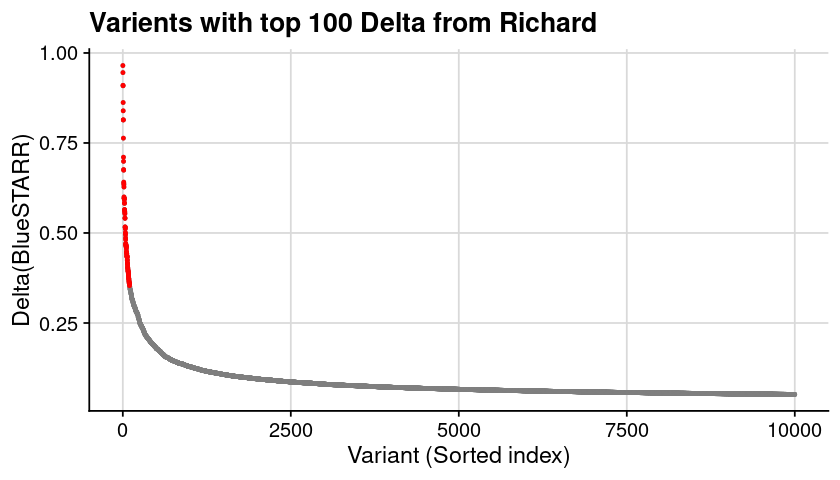

In [22]:
dat = dat_region_variant
dat = head(dat, 10000)
tmp = head(dat, 100)

gpt = ggplot() + 
    geom_point(data = dat, aes(x=1:nrow(dat), y=Delta), color = "grey50", size = 0.5) + 
    geom_point(data = tmp, aes(x=1:nrow(tmp), y=Delta), color = "red", size = 0.5) + 
    labs(x="Variant (Sorted index)", y = "Delta(BlueSTARR)", title = "Varients with top 100 Delta from Richard") +
    theme_cowplot() + 
    background_grid()
options(repr.plot.width = 7, repr.plot.height=4)
print(gpt)